<a href="https://colab.research.google.com/github/yunseo449/ESAA/blob/main/YB_0918(1)_exercises_chipotle_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Visualizing Chipotle's Data

This time we are going to pull data directly from the internet.
Special thanks to: https://github.com/justmarkham for sharing the dataset and materials.

### Step 1. Import the necessary libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# set this so the graphs open internally
%matplotlib inline

### Step 2. Import the dataset from this [address](https://raw.githubusercontent.com/justmarkham/DAT8/master/data/chipotle.tsv).

### Step 3. Assign it to a variable called chipo.

In [2]:
url = 'https://raw.githubusercontent.com/justmarkham/DAT8/master/data/chipotle.tsv'

chipo = pd.read_csv(url, sep = '\t')

### Step 4. See the first 10 entries

In [3]:
chipo.head(10)

,order_id,quantity,item_name,choice_description,item_price
0,1,1,Chips and Fresh Tomato Salsa,NaN,$2.39
1,1,1,Izze,[Clementine],$3.39
2,1,1,Nantucket Nectar,[Apple],$3.39
3,1,1,Chips and Tomatillo-Green Chili Salsa,NaN,$2.39
4,2,2,Chicken Bowl,"[Tomatillo-Red Chili Salsa (Hot), [Black Beans...",$16.98
5,3,1,Chicken Bowl,"[Fresh Tomato Salsa (Mild), [Rice, Cheese, Sou...",$10.98
6,3,1,Side of Chips,NaN,$1.69
7,4,1,Steak Burrito,"[Tomatillo Red Chili Salsa, [Fajita Vegetables...",$11.75
8,4,1,Steak Soft Tacos,"[Tomatillo Green Chili Salsa, [Pinto Beans, Ch...",$9.25
9,5,1,Steak Burrito,"[Fresh Tomato Salsa, [Rice, Black Beans, Pinto...",$9.25


### Step 5. Create a histogram of the top 5 items bought

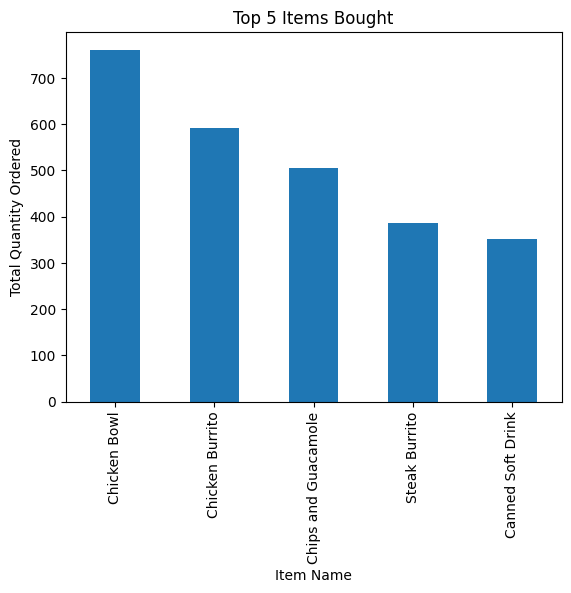

In [4]:
# 1. 아이템별로 그룹화하여 수량(quantity)의 총합을 구하고, 내림차순 정렬 후 상위 5개 추출
top_5_items = chipo.groupby('item_name')['quantity'].sum().sort_values(ascending=False).head(5)

# 2. 막대 그래프 생성
top_5_items.plot(kind='bar')

# 3. 그래프 제목 및 축 라벨 설정
plt.title('Top 5 Items Bought')
plt.xlabel('Item Name')
plt.ylabel('Total Quantity Ordered')

# 4. 그래프 출력
plt.show()

### Step 6. Create a scatterplot with the number of items orderered per order price
#### Hint: Price should be in the X-axis and Items ordered in the Y-axis

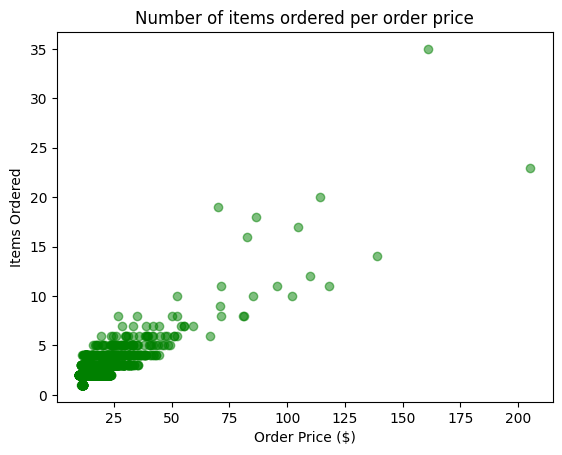

In [5]:
import seaborn as sns
# 1. 가격($ 기호 제거 후 숫자로 변환)
chipo['item_price'] = chipo['item_price'].astype(str).str.replace('$', '', regex=False).astype(float)

# 2. 주문 번호(order_id)별로 총 가격과 수량 합치기
order_grouped = chipo.groupby('order_id').agg({'item_price': 'sum', 'quantity': 'sum'}).reset_index()

# 3. 산점도 그리기 (X축: 가격, Y축: 아이템 개수)
plt.figure(figsize=(8, 5))
sns.scatterplot(x='item_price', y='quantity', data=order_grouped)

plt.title('Scatterplot of Order Price vs Items Ordered')
plt.xlabel('Order Price ($)')
plt.ylabel('Items Ordered')
plt.show()

### Step 7. BONUS: Create a question and a graph to answer your own question.

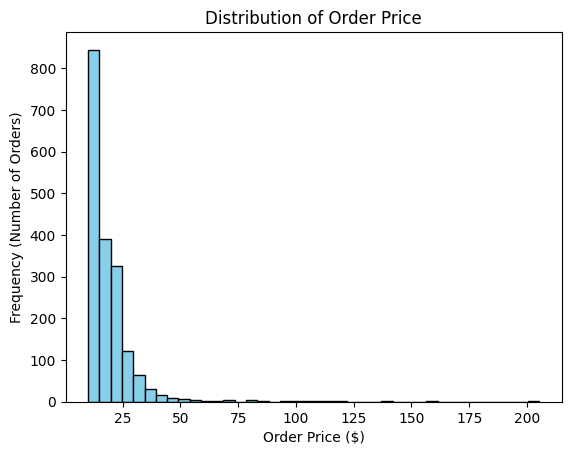

In [6]:
# 한 번 주문할 때 결제하는 총 금액의 분포는 어떻게 될까
# 답변을 위한 그래프: Step 6에서 구한 주문(order_id)별 총액(item_price)의 히스토그램 그리기

plt.hist(orders['item_price'], bins=40, color='skyblue', edgecolor='black')

plt.title('Distribution of Order Price')
plt.xlabel('Order Price ($)')
plt.ylabel('Frequency (Number of Orders)')

# 그래프 출력
plt.show()

=> 1회 주문 시 평균적으로 10~20달러를 지출하는 소규모 소비 패턴